In [1]:
# Importaciones estándar del curso
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import linprog
import pulp

---

## 📊 EJERCICIO 1: MODELO INSUMO-PRODUCTO DE LEONTIEF

**Contexto:** Economía suiza con 3 sectores interdependientes

**Datos:**
- Matriz sectorial (flujos intermedios) en millones de francos suizos
- Vector de demanda final H
- Vector de valor agregado V.A.

### ✅ Paso 1: Crear matriz sectorial y vectores de datos

In [2]:
# Matriz sectorial (matriz de insumos intermedios)
# Filas = sectores que venden, Columnas = sectores que compran
matriz_sectorial = np.array([
    [90, 20, 80],     # Chocolates (C): vende a C, R, SF
    [200, 500, 400],  # Relojes (R): vende a C, R, SF  
    [180, 280, 1000]  # Servicios Financieros (SF): vende a C, R, SF
])

print("Matriz sectorial (millones de francos suizos):")
print(matriz_sectorial)

# Vectores de demanda final y valor agregado
demanda_final = np.array([580, 300, 1000])  # Vector H
valor_agregado = np.array([300, 600, 980])   # Vector V.A.

print("\nVector de demanda final (H):", demanda_final)
print("Vector de valor agregado (V.A.):", valor_agregado)

Matriz sectorial (millones de francos suizos):
[[  90   20   80]
 [ 200  500  400]
 [ 180  280 1000]]

Vector de demanda final (H): [ 580  300 1000]
Vector de valor agregado (V.A.): [300 600 980]


### ✅ Paso 2: Calcular producto total y crear DataFrame completo

In [3]:
# MÉTODO 1: Calcular producto total por FILAS
# X_i = suma de flujos intermedios (ventas a otros sectores) + demanda final
producto_total = matriz_sectorial.sum(axis=1) + demanda_final

print("Producto total (X) - Método por filas:")
print(producto_total)

# MÉTODO 2: Verificación por COLUMNAS
# X_j = suma de flujos intermedios (compras de otros sectores) + valor agregado
verificacion_X = matriz_sectorial.sum(axis=0) + valor_agregado

print("\nVerificación producto total - Método por columnas:")
print(verificacion_X)

# Verificar que ambos métodos dan el mismo resultado
print("\n¿Son iguales?", np.allclose(producto_total, verificacion_X))

Producto total (X) - Método por filas:
[ 770 1400 2460]

Verificación producto total - Método por columnas:
[ 770 1400 2460]

¿Son iguales? True


In [4]:
# Crear DataFrame completo del modelo insumo-producto
sectores = ['Chocolates (C)', 'Relojes (R)', 'Servicios Financieros (SF)']

# DataFrame con la matriz sectorial
df_insumo_producto = pd.DataFrame(
    matriz_sectorial, 
    index=sectores,
    columns=sectores
)

# Agregar columna de demanda final
df_insumo_producto['Demanda Final (H)'] = demanda_final

# Agregar columna de producto total
df_insumo_producto['Producto Total (X)'] = producto_total

# Agregar fila de valor agregado
df_insumo_producto.loc['Valor Agregado (V.A.)'] = list(valor_agregado) + [np.nan, np.nan]

# Agregar fila de producto total (verificación por columnas)
df_insumo_producto.loc['Producto Total (X)'] = list(verificacion_X) + [np.nan, np.nan]

print("="*80)
print("TABLA COMPLETA DEL MODELO INSUMO-PRODUCTO (millones francos suizos)")
print("="*80)
print(df_insumo_producto)

TABLA COMPLETA DEL MODELO INSUMO-PRODUCTO (millones francos suizos)
                            Chocolates (C)  Relojes (R)  \
Chocolates (C)                        90.0         20.0   
Relojes (R)                          200.0        500.0   
Servicios Financieros (SF)           180.0        280.0   
Valor Agregado (V.A.)                300.0        600.0   
Producto Total (X)                   770.0       1400.0   

                            Servicios Financieros (SF)  Demanda Final (H)  \
Chocolates (C)                                    80.0              580.0   
Relojes (R)                                      400.0              300.0   
Servicios Financieros (SF)                      1000.0             1000.0   
Valor Agregado (V.A.)                            980.0                NaN   
Producto Total (X)                              2460.0                NaN   

                            Producto Total (X)  
Chocolates (C)                           770.0  
Relojes (R)     

### ✅ Paso 3: Calcular matriz de coeficientes técnicos (A)

In [5]:
# Coeficientes técnicos: a_ij = Z_ij / X_j
# Cuánto del sector i necesita el sector j para producir 1 unidad
coeficientes_tecnicos = matriz_sectorial / producto_total.reshape(1, -1)

print("MATRIZ DE COEFICIENTES TÉCNICOS (A):")
print("="*50)
print("Filas = sectores proveedores, Columnas = sectores demandantes")
print(f"Dimensiones: {coeficientes_tecnicos.shape}")
print()

# Mostrar con formato más legible
sectores_abrev = ['C', 'R', 'SF']
df_coeficientes = pd.DataFrame(
    coeficientes_tecnicos,
    index=[f"{s} (proveedor)" for s in sectores_abrev],
    columns=[f"{s} (demandante)" for s in sectores_abrev]
)

print("Matriz A de coeficientes técnicos:")
print(df_coeficientes.round(4))

print("\nInterpretación económica:")
print("- a_ij = insumo del sector i necesario para producir 1 CHF del sector j")
print(f"- Ejemplo: a_12 = {coeficientes_tecnicos[0,1]:.4f} CHF de chocolates por cada 1 CHF de relojes")
print(f"- Ejemplo: a_21 = {coeficientes_tecnicos[1,0]:.4f} CHF de relojes por cada 1 CHF de chocolates")

MATRIZ DE COEFICIENTES TÉCNICOS (A):
Filas = sectores proveedores, Columnas = sectores demandantes
Dimensiones: (3, 3)

Matriz A de coeficientes técnicos:
                C (demandante)  R (demandante)  SF (demandante)
C (proveedor)           0.1169          0.0143           0.0325
R (proveedor)           0.2597          0.3571           0.1626
SF (proveedor)          0.2338          0.2000           0.4065

Interpretación económica:
- a_ij = insumo del sector i necesario para producir 1 CHF del sector j
- Ejemplo: a_12 = 0.0143 CHF de chocolates por cada 1 CHF de relojes
- Ejemplo: a_21 = 0.2597 CHF de relojes por cada 1 CHF de chocolates


In [6]:
# Verificación de los coeficientes técnicos
sumas_columnas = coeficientes_tecnicos.sum(axis=0)

print("Verificación - Suma de coeficientes por columna:")
for i, sector in enumerate(sectores_abrev):
    insumos_intermedios_prop = sumas_columnas[i]
    valor_agregado_prop = valor_agregado[i] / producto_total[i]
    total_prop = insumos_intermedios_prop + valor_agregado_prop
    
    print(f"Sector {sector}:")
    print(f"   Insumos intermedios: {insumos_intermedios_prop:.4f} ({insumos_intermedios_prop*100:.2f}%)")
    print(f"   Valor agregado: {valor_agregado_prop:.4f} ({valor_agregado_prop*100:.2f}%)")
    print(f"   Total: {total_prop:.4f} ({total_prop*100:.2f}%)")
    print()

Verificación - Suma de coeficientes por columna:
Sector C:
   Insumos intermedios: 0.6104 (61.04%)
   Valor agregado: 0.3896 (38.96%)
   Total: 1.0000 (100.00%)

Sector R:
   Insumos intermedios: 0.5714 (57.14%)
   Valor agregado: 0.4286 (42.86%)
   Total: 1.0000 (100.00%)

Sector SF:
   Insumos intermedios: 0.6016 (60.16%)
   Valor agregado: 0.3984 (39.84%)
   Total: 1.0000 (100.00%)



### ✅ Paso 4: Aplicar el modelo de Leontief: X = (I - A)^(-1) × H

In [7]:
# Paso 1: Crear matriz identidad
matriz_identidad = np.eye(3)
print("Matriz Identidad (I):")
print(matriz_identidad)

# Paso 2: Calcular (I - A)
matriz_I_menos_A = matriz_identidad - coeficientes_tecnicos
print("\nMatriz (I - A):")
print(pd.DataFrame(matriz_I_menos_A, 
                  index=sectores_abrev, 
                  columns=sectores_abrev).round(4))

# Paso 3: Calcular la matriz inversa de Leontief (I - A)^(-1)
matriz_leontief = np.linalg.inv(matriz_I_menos_A)
print("\nMatriz de Leontief (I - A)^(-1):")
print(pd.DataFrame(matriz_leontief, 
                  index=sectores_abrev, 
                  columns=sectores_abrev).round(4))

# Paso 4: Calcular producción total usando el modelo
producto_total_leontief = matriz_leontief @ demanda_final

print("\nResultados del modelo de Leontief:")
print(f"   Producto total calculado directamente: {producto_total}")
print(f"   Producto total usando Leontief: {producto_total_leontief.round(1)}")
print(f"   ¿Son iguales? {np.allclose(producto_total, producto_total_leontief)}")

Matriz Identidad (I):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Matriz (I - A):
         C       R      SF
C   0.8831 -0.0143 -0.0325
R  -0.2597  0.6429 -0.1626
SF -0.2338 -0.2000  0.5935

Matriz de Leontief (I - A)^(-1):
         C       R      SF
C   1.1677  0.0501  0.0777
R   0.6429  1.7281  0.5087
SF  0.6766  0.6021  1.8870

Resultados del modelo de Leontief:
   Producto total calculado directamente: [ 770 1400 2460]
   Producto total usando Leontief: [ 770. 1400. 2460.]
   ¿Son iguales? True


### ✅ Paso 5: Validación del modelo (determinante, rango, verificación)

In [8]:
# Calcular determinante de (I - A)
determinante = np.linalg.det(matriz_I_menos_A)
print(f"Determinante de (I - A): {determinante:.6f}")

if abs(determinante) > 1e-10:
    print("✅ El modelo es viable (determinante ≠ 0)")
    print("   La matriz (I - A) es invertible")
else:
    print("❌ El modelo NO es viable (determinante ≈ 0)")
    print("   La matriz (I - A) NO es invertible")

# Calcular rango de (I - A)
rango = np.linalg.matrix_rank(matriz_I_menos_A)
print(f"\nRango de (I - A): {rango}")
print(f"Dimensión de la matriz: 3x3")

if rango == 3:
    print("✅ La matriz tiene rango completo (3)")

Determinante de (I - A): 0.298897
✅ El modelo es viable (determinante ≠ 0)
   La matriz (I - A) es invertible

Rango de (I - A): 3
Dimensión de la matriz: 3x3
✅ La matriz tiene rango completo (3)


In [9]:
# Verificar la identidad fundamental del modelo: X - A×X = H
verificacion_identidad = producto_total - (coeficientes_tecnicos @ producto_total)

print("Verificación de la identidad fundamental del modelo de Leontief:")
print("="*60)
print("X - A×X = H")
print(f"\nX - A×X = {verificacion_identidad.round(2)}")
print(f"H       = {demanda_final}")
print(f"\n¿Son iguales? {np.allclose(verificacion_identidad, demanda_final)}")

print("\nInterpretación económica:")
print("El producto total (X) menos lo que se consume internamente (A×X)")
print("es igual a la demanda final (H) que sale de la economía.")

Verificación de la identidad fundamental del modelo de Leontief:
X - A×X = H

X - A×X = [ 580.  300. 1000.]
H       = [ 580  300 1000]

¿Son iguales? True

Interpretación económica:
El producto total (X) menos lo que se consume internamente (A×X)
es igual a la demanda final (H) que sale de la economía.


### ✅ Paso 6: Análisis de cambios en demanda final (shock económico)

In [10]:
# Simular tarifas de Estados Unidos
# Reducciones: Chocolates -5%, Relojes -40%, Servicios Financieros -90%

print("IMPACTO DE TARIFAS DE ESTADOS UNIDOS:")
print("="*50)

# Factores de reducción
reduccion_chocolates = 0.05  # 5%
reduccion_relojes = 0.40     # 40%
reduccion_sf = 0.90          # 90%

# Calcular nuevo vector de demandas finales
demanda_final_original = demanda_final.copy()
demanda_final_nueva = demanda_final_original * np.array([
    1 - reduccion_chocolates,
    1 - reduccion_relojes,
    1 - reduccion_sf
])

print("Vector de demandas finales:")
print(f"   Antes de tarifas: {demanda_final_original}")
print(f"   Después de tarifas: {demanda_final_nueva}")

# Mostrar cambios por sector
print("\nCambios por sector:")
for i, sector in enumerate(sectores_abrev):
    cambio_absoluto = demanda_final_nueva[i] - demanda_final_original[i]
    cambio_porcentual = (cambio_absoluto / demanda_final_original[i]) * 100
    
    print(f"   {sector}: {demanda_final_original[i]:.0f} → {demanda_final_nueva[i]:.0f} CHF")
    print(f"       Cambio: {cambio_absoluto:+.0f} CHF ({cambio_porcentual:+.1f}%)")

# Impacto total
perdida_total = demanda_final_original.sum() - demanda_final_nueva.sum()
print(f"\nPérdida total de demanda final: {perdida_total:.0f} millones CHF")
print(f"Reducción porcentual total: {(perdida_total/demanda_final_original.sum()*100):.1f}%")

IMPACTO DE TARIFAS DE ESTADOS UNIDOS:
Vector de demandas finales:
   Antes de tarifas: [ 580  300 1000]
   Después de tarifas: [551. 180. 100.]

Cambios por sector:
   C: 580 → 551 CHF
       Cambio: -29 CHF (-5.0%)
   R: 300 → 180 CHF
       Cambio: -120 CHF (-40.0%)
   SF: 1000 → 100 CHF
       Cambio: -900 CHF (-90.0%)

Pérdida total de demanda final: 1049 millones CHF
Reducción porcentual total: 55.8%


In [11]:
# Calcular nuevo producto total usando el modelo de Leontief
producto_total_nuevo = matriz_leontief @ demanda_final_nueva

print("NUEVO PRODUCTO TOTAL DESPUÉS DE TARIFAS:")
print("="*50)
print(f"   Producto total ANTES: {producto_total}")
print(f"   Producto total DESPUÉS: {producto_total_nuevo.round(1)}")

# Calcular cambios
cambio_absoluto = producto_total_nuevo - producto_total
cambio_porcentual = (cambio_absoluto / producto_total) * 100

print("\nCambios en producto total por sector:")
for i, sector in enumerate(sectores_abrev):
    print(f"   {sector}: {producto_total[i]:.0f} → {producto_total_nuevo[i]:.1f} CHF")
    print(f"       Cambio: {cambio_absoluto[i]:+.1f} CHF ({cambio_porcentual[i]:+.1f}%)")

NUEVO PRODUCTO TOTAL DESPUÉS DE TARIFAS:
   Producto total ANTES: [ 770 1400 2460]
   Producto total DESPUÉS: [660.2 716.2 669.9]

Cambios en producto total por sector:
   C: 770 → 660.2 CHF
       Cambio: -109.8 CHF (-14.3%)
   R: 1400 → 716.2 CHF
       Cambio: -683.8 CHF (-48.8%)
   SF: 2460 → 669.9 CHF
       Cambio: -1790.1 CHF (-72.8%)


### ✅ Paso 7: Visualización comparativa (antes vs después)

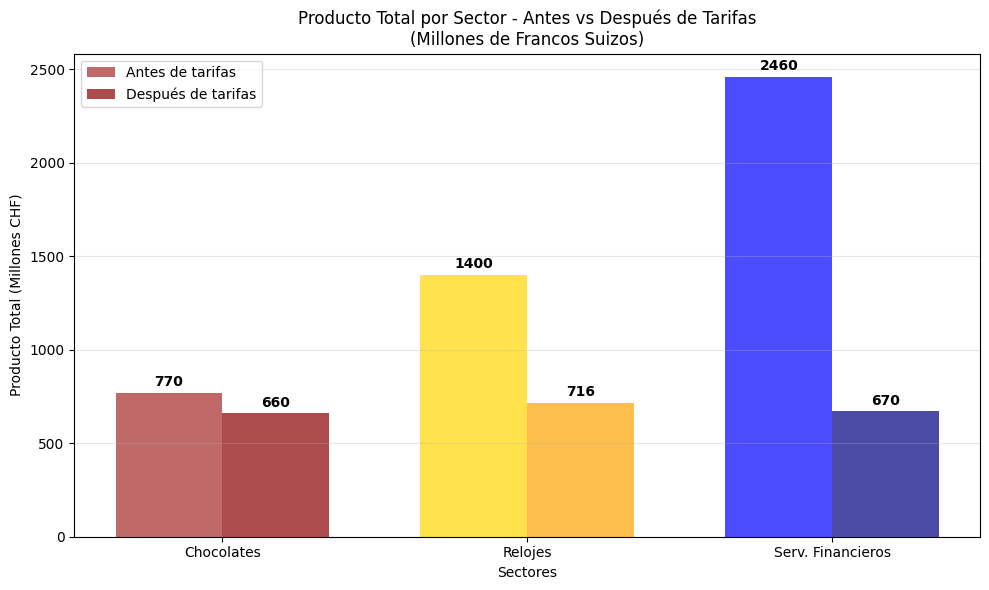

In [12]:
# Gráfico comparativo del producto total
sectores_nombres = ['Chocolates', 'Relojes', 'Serv. Financieros']
x_pos = np.arange(len(sectores_nombres))
ancho_barras = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

barras_antes = ax.bar(x_pos - ancho_barras/2, producto_total, ancho_barras, 
                     label='Antes de tarifas', color=['brown', 'gold', 'blue'], alpha=0.7)
barras_despues = ax.bar(x_pos + ancho_barras/2, producto_total_nuevo, ancho_barras, 
                       label='Después de tarifas', color=['darkred', 'orange', 'navy'], alpha=0.7)

# Etiquetas con valores
for i, (antes, despues) in enumerate(zip(producto_total, producto_total_nuevo)):
    ax.text(i - ancho_barras/2, antes + 20, f'{antes:.0f}', ha='center', va='bottom', fontweight='bold')
    ax.text(i + ancho_barras/2, despues + 20, f'{despues:.0f}', ha='center', va='bottom', fontweight='bold')

ax.set_title('Producto Total por Sector - Antes vs Después de Tarifas\n(Millones de Francos Suizos)')
ax.set_xlabel('Sectores')
ax.set_ylabel('Producto Total (Millones CHF)')
ax.set_xticks(x_pos)
ax.set_xticklabels(sectores_nombres)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### ✅ Paso 8: Cálculo del nuevo valor agregado

In [13]:
# Calcular nuevo valor agregado
# V.A. = X - Σ(insumos intermedios que compra cada sector)
insumos_intermedios_nuevos = coeficientes_tecnicos.T @ producto_total_nuevo
valor_agregado_nuevo = producto_total_nuevo - insumos_intermedios_nuevos

print("NUEVO VALOR AGREGADO:")
print("="*50)
print(f"   Producto total nuevo: {producto_total_nuevo.round(1)}")
print(f"   Insumos intermedios nuevos: {insumos_intermedios_nuevos.round(1)}")
print(f"   Valor agregado nuevo: {valor_agregado_nuevo.round(1)}")

print("\nComparación del valor agregado:")
print(f"   Antes de tarifas: {valor_agregado}")
print(f"   Después de tarifas: {valor_agregado_nuevo.round(1)}")

# Calcular cambios
cambio_va_absoluto = valor_agregado_nuevo - valor_agregado
cambio_va_porcentual = (cambio_va_absoluto / valor_agregado) * 100

print("\nCambios en valor agregado por sector:")
for i, sector in enumerate(sectores_abrev):
    print(f"   {sector}: {valor_agregado[i]:.0f} → {valor_agregado_nuevo[i]:.1f} CHF")
    print(f"       Cambio: {cambio_va_absoluto[i]:+.1f} CHF ({cambio_va_porcentual[i]:+.1f}%)")

# Impacto en el PIB
pib_antes = valor_agregado.sum()
pib_despues = valor_agregado_nuevo.sum()
cambio_pib = pib_despues - pib_antes

print("\nImpacto en el PIB de Suiza:")
print(f"   PIB antes: {pib_antes:,.0f} millones CHF")
print(f"   PIB después: {pib_despues:,.1f} millones CHF")
print(f"   Cambio en PIB: {cambio_pib:+,.1f} CHF ({(cambio_pib/pib_antes*100):+.1f}%)")

NUEVO VALOR AGREGADO:
   Producto total nuevo: [660.2 716.2 669.9]
   Insumos intermedios nuevos: [419.8 399.2 410.2]
   Valor agregado nuevo: [240.4 317.  259.6]

Comparación del valor agregado:
   Antes de tarifas: [300 600 980]
   Después de tarifas: [240.4 317.  259.6]

Cambios en valor agregado por sector:
   C: 300 → 240.4 CHF
       Cambio: -59.6 CHF (-19.9%)
   R: 600 → 317.0 CHF
       Cambio: -283.0 CHF (-47.2%)
   SF: 980 → 259.6 CHF
       Cambio: -720.4 CHF (-73.5%)

Impacto en el PIB de Suiza:
   PIB antes: 1,880 millones CHF
   PIB después: 817.0 millones CHF
   Cambio en PIB: -1,063.0 CHF (-56.5%)


---

## 🎯 EJERCICIO 2: PROGRAMACIÓN LINEAL CON PULP

**Contexto:** Empresa Techint produce acero, cobre y hierro

**Objetivo:** Maximizar beneficio total

**Datos:**
- Beneficios: Acero $5M/ton, Cobre $10M/ton, Hierro $9M/ton
- Costos: Acero $2M/ton, Cobre $3M/ton, Hierro $4M/ton
- Capacidad: 1200 toneladas máximo
- Presupuesto: $1500 millones

### ✅ Paso 1: Definir parámetros del problema

In [14]:
# Beneficios por tonelada
beneficios_acero = 5      # $5 millones por tonelada
beneficios_cobre = 10     # $10 millones por tonelada
beneficios_hierro = 9     # $9 millones por tonelada

beneficios = np.array([beneficios_acero, beneficios_cobre, beneficios_hierro])
print("Beneficios por tonelada:")
print(f"  Acero: ${beneficios_acero} millones/ton")
print(f"  Cobre: ${beneficios_cobre} millones/ton") 
print(f"  Hierro: ${beneficios_hierro} millones/ton")

# Costos de producción por tonelada
costos_acero = 2      # $2 millones por tonelada
costos_cobre = 3      # $3 millones por tonelada
costos_hierro = 4     # $4 millones por tonelada

print(f"\nCostos de producción:")
print(f"  Acero: ${costos_acero} millones/ton")
print(f"  Cobre: ${costos_cobre} millones/ton")
print(f"  Hierro: ${costos_hierro} millones/ton")

# Restricciones
capacidad_maxima = 1200  # toneladas
presupuesto_maximo = 1500  # millones de dólares

print(f"\nRestricciones:")
print(f"  Capacidad máxima: {capacidad_maxima} toneladas")
print(f"  Presupuesto máximo: ${presupuesto_maximo} millones")

Beneficios por tonelada:
  Acero: $5 millones/ton
  Cobre: $10 millones/ton
  Hierro: $9 millones/ton

Costos de producción:
  Acero: $2 millones/ton
  Cobre: $3 millones/ton
  Hierro: $4 millones/ton

Restricciones:
  Capacidad máxima: 1200 toneladas
  Presupuesto máximo: $1500 millones


### ✅ Paso 2: Formular y resolver el problema con PuLP

In [15]:
# PASO 1: Crear el problema de maximización
prob = pulp.LpProblem("Maximizar_Beneficio_Techint", pulp.LpMaximize)

# PASO 2: Definir variables de decisión (cantidades a producir)
x_A = pulp.LpVariable('Acero', lowBound=0)  # x_A ≥ 0
x_C = pulp.LpVariable('Cobre', lowBound=0)  # x_C ≥ 0
x_H = pulp.LpVariable('Hierro', lowBound=0)  # x_H ≥ 0

# PASO 3: Definir función objetivo
# Maximizar: Z = 5*Acero + 10*Cobre + 9*Hierro
prob += 5*x_A + 10*x_C + 9*x_H, "Beneficio_Total"

# PASO 4: Agregar restricciones
# Restricción 1: Capacidad de almacenamiento
prob += x_A + x_C + x_H <= 1200, "Capacidad_Almacenamiento"

# Restricción 2: Presupuesto
prob += 2*x_A + 3*x_C + 4*x_H <= 1500, "Restriccion_Presupuesto"

print("Problema de programación lineal formulado:")
print("="*50)
print(prob)

Problema de programación lineal formulado:
Maximizar_Beneficio_Techint:
MAXIMIZE
5*Acero + 10*Cobre + 9*Hierro + 0
SUBJECT TO
Capacidad_Almacenamiento: Acero + Cobre + Hierro <= 1200

Restriccion_Presupuesto: 2 Acero + 3 Cobre + 4 Hierro <= 1500

VARIABLES
Acero Continuous
Cobre Continuous
Hierro Continuous



In [16]:
# PASO 5: Resolver el problema
solver = pulp.PULP_CBC_CMD(msg=0)  # Sin mensajes de salida
prob.solve(solver)

# PASO 6: Verificar y extraer resultados
print("RESOLVIENDO EL PROBLEMA DE OPTIMIZACIÓN:")
print("="*50)

if prob.status == pulp.LpStatusOptimal:
    # Extraer valores óptimos
    toneladas_acero = pulp.value(x_A)
    toneladas_cobre = pulp.value(x_C)
    toneladas_hierro = pulp.value(x_H)
    beneficio_total = pulp.value(prob.objective)
    
    print("✅ ¡SOLUCIÓN ENCONTRADA!")
    print()
    print("Cantidades óptimas a producir:")
    print(f"  🔩 Acero: {toneladas_acero:.1f} toneladas")
    print(f"  🟠 Cobre: {toneladas_cobre:.1f} toneladas")
    print(f"  ⚫ Hierro: {toneladas_hierro:.1f} toneladas")
    print()
    print(f"💰 Beneficio máximo total: ${beneficio_total:,.1f} millones")
    
    # Verificar uso de recursos
    print("\n📊 Verificación de uso de recursos:")
    
    capacidad_usada = toneladas_acero + toneladas_cobre + toneladas_hierro
    porcentaje_capacidad = (capacidad_usada / 1200) * 100
    print(f"  Almacenamiento: {capacidad_usada:.1f}/1200 toneladas ({porcentaje_capacidad:.1f}%)")
    
    presupuesto_usado = (costos_acero * toneladas_acero + 
                        costos_cobre * toneladas_cobre + 
                        costos_hierro * toneladas_hierro)
    porcentaje_presupuesto = (presupuesto_usado / 1500) * 100
    print(f"  Presupuesto: ${presupuesto_usado:.1f}/1500 millones ({porcentaje_presupuesto:.1f}%)")
    
    # Identificar limitaciones activas
    print("\n🔍 Análisis de limitaciones:")
    if porcentaje_capacidad > 99:
        print("  ⚠️  El almacenamiento está al límite (restricción activa)")
    if porcentaje_presupuesto > 99:
        print("  ⚠️  El presupuesto está al límite (restricción activa)")
    
    # Guardar resultados para usar después
    x_optimo = np.array([toneladas_acero, toneladas_cobre, toneladas_hierro])
    beneficio_maximo = beneficio_total
    
else:
    print("❌ Error: No se pudo encontrar una solución óptima")
    print(f"Estado: {pulp.LpStatus[prob.status]}")

RESOLVIENDO EL PROBLEMA DE OPTIMIZACIÓN:
✅ ¡SOLUCIÓN ENCONTRADA!

Cantidades óptimas a producir:
  🔩 Acero: 0.0 toneladas
  🟠 Cobre: 500.0 toneladas
  ⚫ Hierro: 0.0 toneladas

💰 Beneficio máximo total: $5,000.0 millones

📊 Verificación de uso de recursos:
  Almacenamiento: 500.0/1200 toneladas (41.7%)
  Presupuesto: $1500.0/1500 millones (100.0%)

🔍 Análisis de limitaciones:
  ⚠️  El presupuesto está al límite (restricción activa)


### ✅ Paso 3: Visualización de la solución óptima

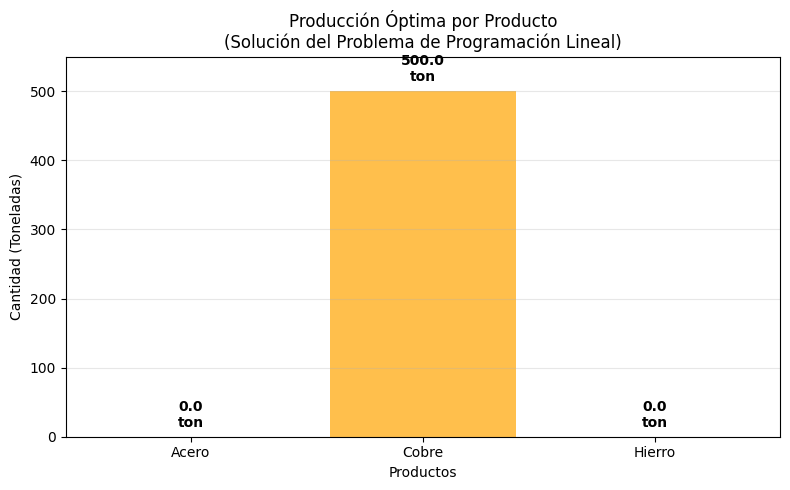

Producción total: 500.00 toneladas
Utilización de capacidad: 41.7%


In [17]:
# Gráfico de barras con las cantidades óptimas
productos = ['Acero', 'Cobre', 'Hierro']
cantidades_optimas = x_optimo
colores = ['gray', 'orange', 'brown']

plt.figure(figsize=(8, 5))
barras = plt.bar(productos, cantidades_optimas, color=colores, alpha=0.7)

# Etiquetas con valores
for i, valor in enumerate(cantidades_optimas):
    plt.text(i, valor + 10, f'{valor:.1f}\nton', ha='center', va='bottom', fontweight='bold')

plt.title('Producción Óptima por Producto\n(Solución del Problema de Programación Lineal)')
plt.xlabel('Productos')
plt.ylabel('Cantidad (Toneladas)')
plt.grid(True, axis='y', alpha=0.3)
plt.ylim(0, max(cantidades_optimas) + 50)

plt.tight_layout()
plt.show()

# Información adicional
produccion_total = cantidades_optimas.sum()
print(f"Producción total: {produccion_total:.2f} toneladas")
print(f"Utilización de capacidad: {produccion_total/1200*100:.1f}%")

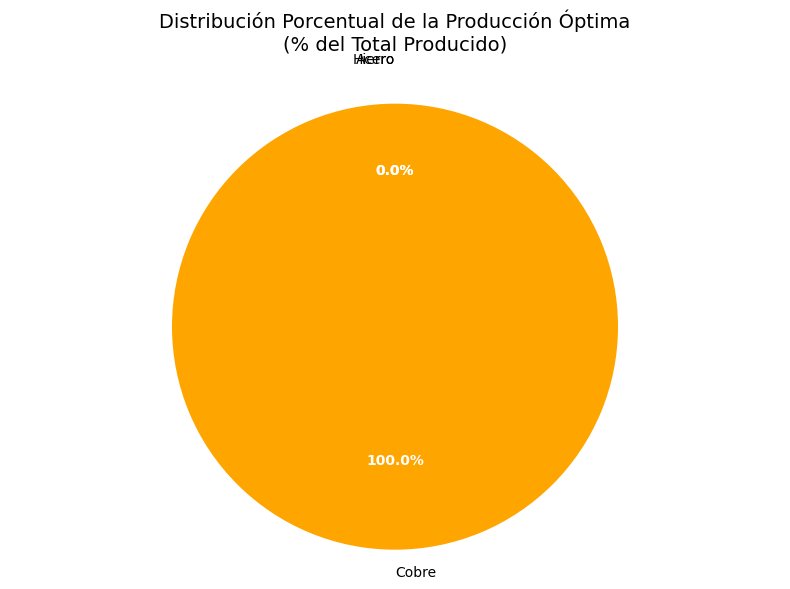

Distribución porcentual de la producción:
   Acero: 0.0 ton (0.0%)
   Cobre: 500.0 ton (100.0%)
   Hierro: 0.0 ton (0.0%)


In [18]:
# Gráfico de torta con distribución porcentual
produccion_total = cantidades_optimas.sum()
porcentajes = (cantidades_optimas / produccion_total) * 100

plt.figure(figsize=(8, 6))
wedges, texts, autotexts = plt.pie(porcentajes, 
                                  labels=productos,
                                  colors=colores,
                                  autopct='%1.1f%%',
                                  startangle=90,
                                  explode=[0.05, 0.05, 0.05])

plt.title('Distribución Porcentual de la Producción Óptima\n(% del Total Producido)', fontsize=14)

# Mejorar formato del texto
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.axis('equal')
plt.tight_layout()
plt.show()

# Resumen numérico
print("Distribución porcentual de la producción:")
for producto, cantidad, porcentaje in zip(productos, cantidades_optimas, porcentajes):
    print(f"   {producto}: {cantidad:.1f} ton ({porcentaje:.1f}%)")

### ✅ Paso 4: Análisis de sensibilidad - Aumento del tipo de cambio

In [19]:
# Nuevos costos con aumento del tipo de cambio
print("IMPACTO DEL AUMENTO DEL TIPO DE CAMBIO:")
print("="*50)

# Aumentos en los costos
aumento_acero = 90   # +90%
aumento_cobre = 60   # +60% 
aumento_hierro = 50  # +50%

costos_nuevos_acero = costos_acero * (1 + aumento_acero/100)
costos_nuevos_cobre = costos_cobre * (1 + aumento_cobre/100)
costos_nuevos_hierro = costos_hierro * (1 + aumento_hierro/100)

print("📈 Aumentos en los costos de producción:")
print(f"  Acero: ${costos_acero} → ${costos_nuevos_acero:.1f} millones/ton (+{aumento_acero}%)")
print(f"  Cobre: ${costos_cobre} → ${costos_nuevos_cobre:.1f} millones/ton (+{aumento_cobre}%)")
print(f"  Hierro: ${costos_hierro} → ${costos_nuevos_hierro:.1f} millones/ton (+{aumento_hierro}%)")

# Resolver nuevo problema con costos aumentados
prob_nuevo = pulp.LpProblem("Maximizar_Beneficio_Nuevo", pulp.LpMaximize)

x_A_nuevo = pulp.LpVariable('Acero', lowBound=0)
x_C_nuevo = pulp.LpVariable('Cobre', lowBound=0)
x_H_nuevo = pulp.LpVariable('Hierro', lowBound=0)

# Los beneficios no cambian, solo los costos
prob_nuevo += 5*x_A_nuevo + 10*x_C_nuevo + 9*x_H_nuevo, "Beneficio_Total"

# Nueva restricción presupuestaria con costos aumentados
prob_nuevo += x_A_nuevo + x_C_nuevo + x_H_nuevo <= 1200, "Capacidad"
prob_nuevo += costos_nuevos_acero*x_A_nuevo + costos_nuevos_cobre*x_C_nuevo + costos_nuevos_hierro*x_H_nuevo <= 1500, "Presupuesto_Nuevo"

solver = pulp.PULP_CBC_CMD(msg=0)
prob_nuevo.solve(solver)

if prob_nuevo.status == pulp.LpStatusOptimal:
    toneladas_acero_nuevo = pulp.value(x_A_nuevo)
    toneladas_cobre_nuevo = pulp.value(x_C_nuevo)
    toneladas_hierro_nuevo = pulp.value(x_H_nuevo)
    beneficio_total_nuevo = pulp.value(prob_nuevo.objective)
    
    print("\n✅ Nueva solución encontrada:")
    print(f"  🔩 Acero: {toneladas_acero_nuevo:.1f} toneladas")
    print(f"  🟠 Cobre: {toneladas_cobre_nuevo:.1f} toneladas") 
    print(f"  ⚫ Hierro: {toneladas_hierro_nuevo:.1f} toneladas")
    print(f"  💰 Nuevo beneficio: ${beneficio_total_nuevo:,.1f} millones")
    
    # Comparar con solución anterior
    print("\n📉 ¿En cuánto disminuyó la producción?")
    produccion_antes = [toneladas_acero, toneladas_cobre, toneladas_hierro]
    produccion_despues = [toneladas_acero_nuevo, toneladas_cobre_nuevo, toneladas_hierro_nuevo]
    
    for i, producto in enumerate(productos):
        cambio = produccion_despues[i] - produccion_antes[i]
        if produccion_antes[i] > 0:
            porcentaje_cambio = (cambio / produccion_antes[i]) * 100
            print(f"  {producto}: {produccion_antes[i]:.1f} → {produccion_despues[i]:.1f} ton ({cambio:+.1f} ton, {porcentaje_cambio:+.1f}%)")
    
    # Impacto en beneficios
    perdida_beneficio = beneficio_maximo - beneficio_total_nuevo
    porcentaje_perdida = (perdida_beneficio / beneficio_maximo) * 100
    print(f"\n💸 Pérdida de beneficio: ${perdida_beneficio:,.1f} millones ({porcentaje_perdida:.1f}%)")
    
    x_optimo_nuevo = np.array([toneladas_acero_nuevo, toneladas_cobre_nuevo, toneladas_hierro_nuevo])
    
else:
    print("❌ No se pudo resolver el problema")

IMPACTO DEL AUMENTO DEL TIPO DE CAMBIO:
📈 Aumentos en los costos de producción:
  Acero: $2 → $3.8 millones/ton (+90%)
  Cobre: $3 → $4.8 millones/ton (+60%)
  Hierro: $4 → $6.0 millones/ton (+50%)

✅ Nueva solución encontrada:
  🔩 Acero: 0.0 toneladas
  🟠 Cobre: 312.5 toneladas
  ⚫ Hierro: 0.0 toneladas
  💰 Nuevo beneficio: $3,125.0 millones

📉 ¿En cuánto disminuyó la producción?
  Cobre: 500.0 → 312.5 ton (-187.5 ton, -37.5%)

💸 Pérdida de beneficio: $1,875.0 millones (37.5%)


### ✅ Paso 5: Problema de minimización con restricciones mínimas

In [20]:
# Nuevo problema: MINIMIZAR presupuesto manteniendo producción mínima
print("NUEVO PROBLEMA: MINIMIZAR GASTOS")
print("="*50)

# Nuevas condiciones
print("Nuevas reglas:")
print("   🎯 OBJETIVO: Minimizar el presupuesto")
print("   📦 CAPACIDAD: Máximo 800 toneladas")
print("   ⚠️  MÍNIMOS OPERATIVOS:")
print("      • Mínimo 4 toneladas de acero")
print("      • Mínimo 2 toneladas de cobre") 
print("      • Mínimo 8 toneladas de hierro")

# Crear problema de minimización
prob_min = pulp.LpProblem("Minimizar_Costos", pulp.LpMinimize)

# Variables con límites inferiores (mínimos)
x_A_min = pulp.LpVariable('Acero', lowBound=4)  # Mínimo 4 toneladas
x_C_min = pulp.LpVariable('Cobre', lowBound=2)  # Mínimo 2 toneladas
x_H_min = pulp.LpVariable('Hierro', lowBound=8)  # Mínimo 8 toneladas

# Función objetivo: minimizar costos (con costos aumentados)
prob_min += costos_nuevos_acero*x_A_min + costos_nuevos_cobre*x_C_min + costos_nuevos_hierro*x_H_min, "Costo_Total"

# Restricción de capacidad reducida
prob_min += x_A_min + x_C_min + x_H_min <= 800, "Capacidad_Reducida"

# Resolver
solver = pulp.PULP_CBC_CMD(msg=0)
prob_min.solve(solver)

if prob_min.status == pulp.LpStatusOptimal:
    toneladas_acero_min = pulp.value(x_A_min)
    toneladas_cobre_min = pulp.value(x_C_min)
    toneladas_hierro_min = pulp.value(x_H_min)
    presupuesto_minimo = pulp.value(prob_min.objective)
    
    print("\n✅ ¡SOLUCIÓN DE MÍNIMO COSTO ENCONTRADA!")
    print("="*50)
    print("Producción mínima para mantener operativa la empresa:")
    print(f"  🔩 Acero: {toneladas_acero_min:.1f} toneladas")
    print(f"  🟠 Cobre: {toneladas_cobre_min:.1f} toneladas")
    print(f"  ⚫ Hierro: {toneladas_hierro_min:.1f} toneladas")
    print()
    print(f"💸 Presupuesto mínimo necesario: ${presupuesto_minimo:,.1f} millones")
    
    # Verificación
    capacidad_usada_min = toneladas_acero_min + toneladas_cobre_min + toneladas_hierro_min
    porcentaje_capacidad_min = (capacidad_usada_min / 800) * 100
    
    print("\n📊 Verificación:")
    print(f"  Capacidad utilizada: {capacidad_usada_min:.1f}/800 ton ({porcentaje_capacidad_min:.1f}%)")
    print(f"  ✓ Acero: {toneladas_acero_min:.1f} ≥ 4 toneladas")
    print(f"  ✓ Cobre: {toneladas_cobre_min:.1f} ≥ 2 toneladas")
    print(f"  ✓ Hierro: {toneladas_hierro_min:.1f} ≥ 8 toneladas")
    
    # Beneficio con producción mínima
    beneficio_minimo = (beneficios_acero * toneladas_acero_min + 
                       beneficios_cobre * toneladas_cobre_min + 
                       beneficios_hierro * toneladas_hierro_min)
    
    print(f"\n💰 Beneficio con producción mínima: ${beneficio_minimo:,.1f} millones")
    
    print("\n💡 Conclusión:")
    print(f"  Para mantener la empresa operativa se necesitan al menos")
    print(f"  ${presupuesto_minimo:,.1f} millones de presupuesto")
    
else:
    print("❌ No se pudo encontrar una solución")

NUEVO PROBLEMA: MINIMIZAR GASTOS
Nuevas reglas:
   🎯 OBJETIVO: Minimizar el presupuesto
   📦 CAPACIDAD: Máximo 800 toneladas
   ⚠️  MÍNIMOS OPERATIVOS:
      • Mínimo 4 toneladas de acero
      • Mínimo 2 toneladas de cobre
      • Mínimo 8 toneladas de hierro

✅ ¡SOLUCIÓN DE MÍNIMO COSTO ENCONTRADA!
Producción mínima para mantener operativa la empresa:
  🔩 Acero: 4.0 toneladas
  🟠 Cobre: 2.0 toneladas
  ⚫ Hierro: 8.0 toneladas

💸 Presupuesto mínimo necesario: $72.8 millones

📊 Verificación:
  Capacidad utilizada: 14.0/800 ton (1.8%)
  ✓ Acero: 4.0 ≥ 4 toneladas
  ✓ Cobre: 2.0 ≥ 2 toneladas
  ✓ Hierro: 8.0 ≥ 8 toneladas

💰 Beneficio con producción mínima: $112.0 millones

💡 Conclusión:
  Para mantener la empresa operativa se necesitan al menos
  $72.8 millones de presupuesto

✅ ¡SOLUCIÓN DE MÍNIMO COSTO ENCONTRADA!
Producción mínima para mantener operativa la empresa:
  🔩 Acero: 4.0 toneladas
  🟠 Cobre: 2.0 toneladas
  ⚫ Hierro: 8.0 toneladas

💸 Presupuesto mínimo necesario: $72.8 mill

---

## 📝 RESUMEN DE MÉTODOS CLAVE

### **Modelo de Leontief:**
1. Matriz sectorial → Coeficientes técnicos (A = Z / X)
2. Matriz identidad → (I - A) → Inversa de Leontief
3. Producción total: X = (I - A)^(-1) × H
4. Validación: determinante, rango, identidad X - A×X = H

### **Programación Lineal:**
1. Crear problema: `LpProblem("nombre", LpMaximize/LpMinimize)`
2. Variables: `LpVariable('nombre', lowBound=0)`
3. Función objetivo: `prob += expresión, "nombre"`
4. Restricciones: `prob += expresión <= valor, "nombre"`
5. Resolver: `prob.solve(pulp.PULP_CBC_CMD(msg=0))`
6. Resultados: `pulp.value(variable)` y `pulp.value(prob.objective)`

### **Visualizaciones:**
- Barras comparativas (antes/después)
- Tortas (distribución porcentual)
- Títulos y etiquetas en español
- Grid con `alpha=0.3`

---

## ✅ CHECKLIST PARA EL EXAMEN

**Antes de entregar:**
- [ ] Todas las celdas ejecutadas sin errores
- [ ] Nombres de variables descriptivos (no x, y, z)
- [ ] Comentarios explicando cada paso
- [ ] Verificaciones de dimensiones y validez
- [ ] Gráficos con títulos y etiquetas en español
- [ ] Interpretaciones económicas incluidas
- [ ] Solo métodos enseñados por el profesor
- [ ] Resultados impresos claramente